In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.optim import Adam
from Seq2Seq import Seq2Seq
from torch.utils.data import DataLoader, TensorDataset

import io
import imageio
from ipywidgets import widgets, HBox

import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Use GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
# Load Data as Numpy Array
# sequences, seq_len, channels, height, width
data_CH4 = np.load("./data/input_convlstm/CH4_stacked_Poznan.npy").transpose(0,2,1,3,4)
# Shuffle Data
data_CH4 = np.float32(data_CH4/255.0)
np.random.shuffle(data_CH4)

targets_CH4 = torch.from_numpy(data_CH4[:, :, 19, :, :])
data_CH4 = torch.from_numpy(data_CH4[:, :, :19, :, :])

dataset = TensorDataset(data_CH4, targets_CH4)
#print(dataset.shape)

# Train, Test, Validation splits
#train_data = data_CH4[:550]         
#train_targets = targets_CH4[:550]         
#val_data = data_CH4[550:650]       
#val_data = data_CH4[550:650]       
#test_data = data_CH4[650:]     

def collate(batch):
    # Add channel dim, scale pixels between 0 and 1, send to GPU
    batch = torch.tensor(batch)#.unsqueeze(1)
    #batch = batch.permute(0,2,1,3,4)
    print(batch.shape)
    batch = batch.to(device)                     

    # Randomly pick 10 frames as input, 11th frame is target
    rand = np.random.randint(10,20)                     
    # return batch[:,:,rand-10:rand], batch[:,:,rand]     
    return batch[:, :, rand-10:rand, :, :], batch[:, :, rand, :, :]     


loader = DataLoader(dataset, batch_size=16, shuffle=True)
# Training Data Loader
#train_loader = DataLoader(train_data, shuffle=True, 
#                        batch_size=16)#, collate_fn=collate)

# Validation Data Loader
#val_loader = DataLoader(val_data, shuffle=True, 
#                        batch_size=16)#, collate_fn=collate)



torch.Size([16, 1, 19, 64, 64])
torch.Size([1, 19, 64, 64])


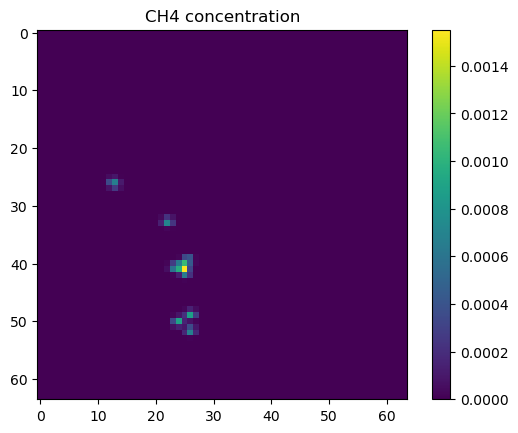

torch.Size([16, 1, 19, 64, 64])
torch.Size([1, 19, 64, 64])


/home/hiroselab/miniconda3/envs/convlstm/lib/python3.13/site-packages/matplotlib/animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


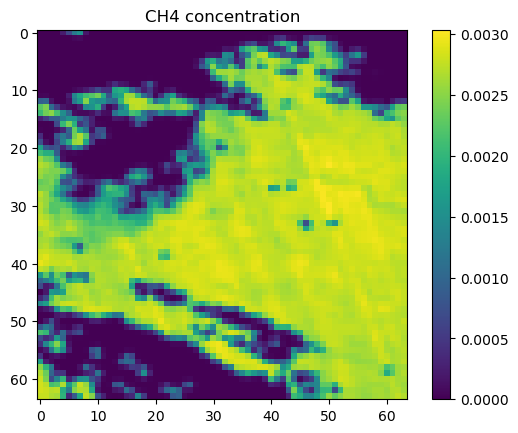

torch.Size([16, 1, 19, 64, 64])
torch.Size([1, 19, 64, 64])


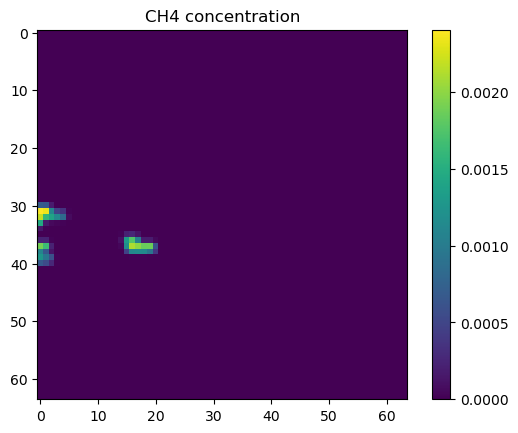

torch.Size([16, 1, 19, 64, 64])
torch.Size([1, 19, 64, 64])


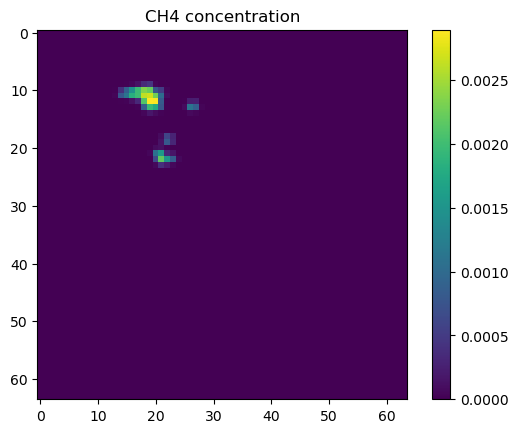

torch.Size([16, 1, 19, 64, 64])
torch.Size([1, 19, 64, 64])


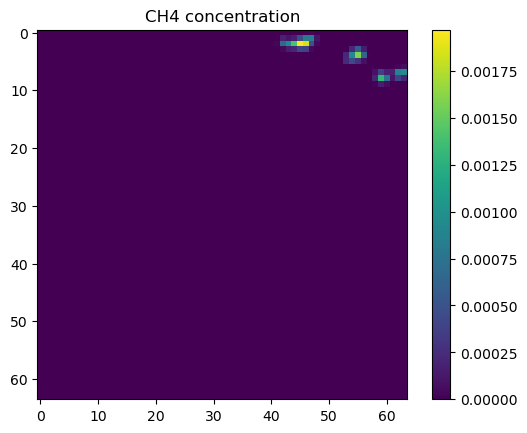

In [6]:
def create_animation(images, interval=100):
    fig, ax = plt.subplots()
    img_display = ax.imshow(images[0, 0])
    fig.colorbar(img_display)
    plt.title("CH4 concentration")
    
    def update(frame):
        img_display.set_array(images[frame,0])
        return img_display
    
    ani = animation.FuncAnimation(fig, update, frames=len(images), interval=interval, blit=False)
    plt.show()
    #ani.save("./output/2024_Svalbard_mean.gif")
    return ani

# Get a batch
input, _ = next(iter(loader))

# Reverse process before displaying
#input = input.cpu().numpy() * 255.0     

for video in input[:5]: # Loop over videos
    #video = video.squeeze(1)
    print(input.shape)
    print(video.shape)
    create_animation(video)
        

In [10]:
def custom_imshow(tensor):
    if tensor.dim() == 4:
        count = 1
        for i in range(tensor.size(0)):
            img = tensor[i].numpy()
            plt.subplot(1, tensor.size(0), count)
            img = img / 2 + 0.5     # unnormalize
            img = np.transpose(img, (1, 2, 0))
            count += 1
            plt.imshow(img)
            plt.axis('off')

    if tensor.dim() == 5:
        count = 1
        for i in range(tensor.size(0)):
            for j in range(tensor.size(1)):
                img = tensor[i][j].numpy()
                plt.subplot(tensor.size(0), tensor.size(1), count)
                img = img / 2 + 0.5  # unnormalize
                img = np.transpose(img, (1, 2, 0))

                plt.imshow(img)
                plt.axis('off')
                count +=1

custom_imshow(dataset)

AttributeError: 'TensorDataset' object has no attribute 'dim'

In [11]:
# The input video frames are grayscale, thus single channel
model = Seq2Seq(num_channels=1, num_kernels=64, 
kernel_size=(3, 3), padding=(1, 1), activation="relu", 
frame_size=(64, 64), num_layers=3).to(device)

optim = Adam(model.parameters(), lr=1e-5)

# Binary Cross Entropy, target pixel values either 0 or 1
criterion = nn.BCELoss(reduction='sum')

torch.Size([16, 1, 19, 64, 64])
torch.Size([16, 1, 64, 64])
tensor([[[[0.5162, 0.1388, 0.5962,  ..., 0.6225, 0.5950, 0.4334],
          [0.0817, 0.2313, 0.3217,  ..., 0.8318, 0.7233, 0.8960],
          [0.0869, 0.5747, 0.5975,  ..., 0.6600, 0.3591, 0.6410],
          ...,
          [0.3399, 0.6031, 0.6918,  ..., 0.9001, 0.2318, 0.3456],
          [0.0683, 0.0612, 0.0092,  ..., 0.2656, 0.1937, 0.7281],
          [0.3605, 0.6872, 0.3525,  ..., 0.3821, 0.2719, 0.5007]]],


        [[[0.5162, 0.1388, 0.5962,  ..., 0.6225, 0.5950, 0.4334],
          [0.0817, 0.2313, 0.3217,  ..., 0.8318, 0.7233, 0.8960],
          [0.0869, 0.5747, 0.5975,  ..., 0.6599, 0.3591, 0.6410],
          ...,
          [0.3375, 0.6070, 0.6965,  ..., 0.9005, 0.2447, 0.3561],
          [0.0695, 0.0618, 0.0097,  ..., 0.2631, 0.2046, 0.7324],
          [0.3628, 0.6881, 0.3586,  ..., 0.3909, 0.2811, 0.5113]]],


        [[[0.5163, 0.1379, 0.5932,  ..., 0.6225, 0.5950, 0.4334],
          [0.0818, 0.2330, 0.3248,  ..., 0.8

NameError: name 'val_loader' is not defined

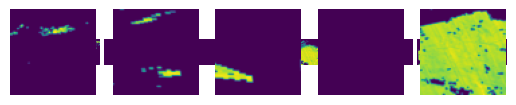

In [12]:
#33 min per epoch
num_epochs = 5

for epoch in range(1, num_epochs+1):
    
    train_loss = 0                                                 
    model.train()
    print(loader)
    #for batch_num, (input, target) in enumerate(train_loader):
    #for input, target in train_loader:
    for input, target in loader:
        #print(input[0, 0, 0, :, :].max())
        custom_imshow(target)
        output = model(input)
        output = output.nan_to_num(nan=0.0)
        print(input.shape)
        print(target.shape)
        print(output)
        loss = criterion(output.flatten(), target.flatten())       
        loss.backward()                                            
        optim.step()                                               
        optim.zero_grad()                                           
        train_loss += loss.item()                                 
    train_loss /= len(loader.dataset)                       

    val_loss = 0                                                 
    model.eval()                                                   
    with torch.no_grad():                                          
        for input, target in val_loader:                          
            output = model(input)                                   
            loss = criterion(output.flatten(), target.flatten())   
            val_loss += loss.item()                                
    val_loss /= len(val_loader.dataset)                            

    print("Epoch:{} Training Loss:{:.2f} Validation Loss:{:.2f}\n".format(
        epoch, train_loss, val_loss))

In [20]:
def collate_test(batch):

    # Last 10 frames are target
    target = np.array(batch)[:,10:]                     
    
    # Add channel dim, scale pixels between 0 and 1, send to GPU
    batch = torch.tensor(batch).unsqueeze(1)          
    batch = batch / 255.0                             
    batch = batch.to(device)                          
    return batch, target

# Test Data Loader
test_loader = DataLoader(test_data,shuffle=True, 
                         batch_size=3, collate_fn=collate_test)

# Get a batch
batch, target = next(iter(test_loader))

# Initialize output sequence
output = np.zeros(target.shape, dtype=np.uint8)

# Loop over timesteps
for timestep in range(target.shape[1]):
  input = batch[:,:,timestep:timestep+10]   
  #output[:,timestep]=(model(input).squeeze(1).cpu()>0.5)*255.0
  output[:,timestep]=(model(input).cpu()>0.5)*255.0

ValueError: only one element tensors can be converted to Python scalars

In [ ]:
for video in output[:5]: # Loop over videos
    print(input.shape)
    print(video.shape)
    create_animation(video)